# 04 — A stable map of the equity universe

**Tool:** `quantroll.RollingEmbedding` (UMAP backend) · **Data:** the same 42 large-caps as notebook 03, quarterly behavior features (trailing return, vol, beta, momentum), 2012 → today.

## What this notebook is about

Notebooks 01–03 produced numbers. This one produces a *picture*: every stock is a dot on a two-dimensional map, arranged so that **stocks that behave similarly sit near each other**.

The underlying task is *dimension reduction for visualization*. Each stock lives in a four-dimensional feature space (trailing return, volatility, beta, momentum), which we cannot draw. So we ask an algorithm to find a two-dimensional arrangement of the 42 points that preserves, as faithfully as possible, *who is close to whom* in the original four dimensions. We use **UMAP** as the mapping engine. Where PCA (notebook 01) is a *linear* method — its axes are flat directions through the data, and it preserves the large-scale variance structure — UMAP is *nonlinear*: it first builds a graph connecting each stock to its nearest neighbors in feature space, then lays that graph out in two dimensions so that neighbors stay together. It preserves *local neighborhoods*, which is exactly what a peer-structure map needs, at the price of axes that mean nothing at all.

Maps like this are how humans audit a universe: spot the outlier with no neighbors, watch a name migrate between styles, see a whole neighborhood dissolve in a regime break.

## The catch — worse here than anywhere else in the library

UMAP's objective cares only about the *distances between points* — and distances are unchanged if you rotate the whole map, flip it in a mirror, or slide it sideways. Every valid map therefore has infinitely many equally valid twins. On top of that, the optimizer is stochastic, so re-running it on the data plus one new quarter can land on a layout that looks nothing like last quarter's: entire clusters teleport. Re-embed each quarter naively and the sequence of maps churns so violently that a stock's trajectory across them is meaningless.

`RollingEmbedding` stabilizes any backend with two mechanisms. Each refit is **warm-started** from the previous layout — points begin where they were, so the optimizer refines the existing map rather than inventing a new one. Then the finished layout is aligned to the previous one by **Procrustes analysis**: a small, closed-form calculation that finds the single rotation/reflection/shift bringing the new map as close as possible to the old one, and removes it. Whatever movement survives that alignment cannot be explained by the map's arbitrary degrees of freedom — so *movement on the map means movement in behavior*.

> *Educational example, not investment advice.*

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantdata as qd
from quantroll import RollingEmbedding

warnings.filterwarnings("ignore")
qd.use_style()
PAL, SEC_COLOR = qd.PALETTE, qd.SECTOR_COLOR

px = qd.load_prices("stock")
spy = qd.load_prices("etf")["SPY"].pct_change(fill_method=None).iloc[1:]
rets = qd.daily_returns(px)
H = 126
feats = {"ann_ret": rets.rolling(H).mean() * 252,
         "ann_vol": rets.rolling(H).std() * np.sqrt(252),
         "beta": rets.rolling(H).cov(spy).div(spy.rolling(H).var(), axis=0),
         "mom": rets.rolling(H).sum()}
frames = []
for d in rets.resample("QE").last().index:
    if d < rets.index[H] or d > rets.index[-1]:
        continue
    idx = rets.index.asof(d)
    f = pd.DataFrame({k: v.loc[idx] for k, v in feats.items()}).dropna()
    z = (f - f.mean()) / f.std(ddof=0)
    z.index = pd.MultiIndex.from_product([[idx], z.index], names=["date", "ticker"])
    frames.append(z)
panel = pd.concat(frames)

t0 = time.perf_counter()
emb = RollingEmbedding(
    backend="umap", seed=0,
    backend_kwargs=dict(n_neighbors=10, min_dist=0.15, n_epochs=200),
).fit(panel)
print(f"{len(frames)} quarterly maps of {len(emb.entity_names_)} stocks, "
      f"stabilized UMAP fit in {time.perf_counter() - t0:.1f}s")

56 quarterly maps of 42 stocks, stabilized UMAP fit in 6.5s


*(No `umap-learn` installed? Change `backend="umap"` to `backend="pca"` — every cell below runs unchanged; the map is then a linear projection with the same stabilization.)*

## 1. The map itself

Below is the most recent quarter's map. Each dot is a stock, and the colors mark GICS sectors. Keep one thing in mind throughout: **the model never saw the sector labels.** They are painted on afterwards, precisely so that we can check whether the structure the algorithm discovered agrees with them — and learn something from the places where it does not.

mean distance within a sector 1.81 vs across sectors 4.01 — sector neighborhoods emerge without the model ever seeing a sector label


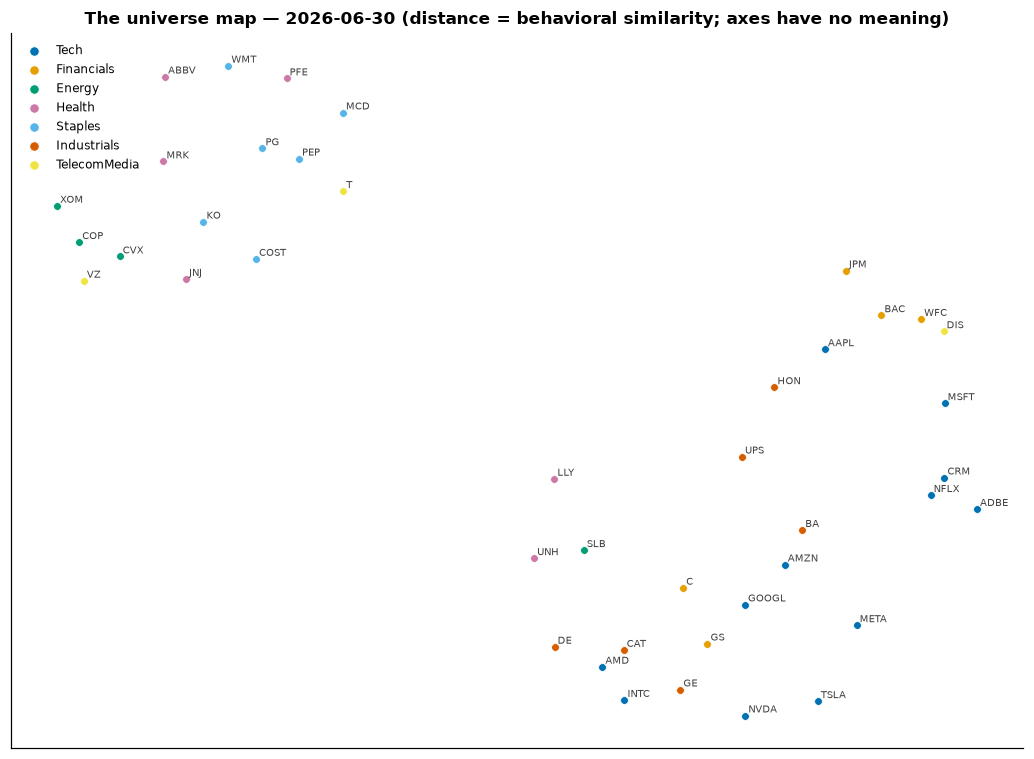

In [2]:
sec = pd.Series({t: qd.STOCK_SECTOR[t] for t in emb.entity_names_})
E = emb.embeddings_

def draw_map(ax, t, label_all=False):
    coords = pd.DataFrame(E[t], index=emb.entity_names_, columns=["x", "y"]).dropna()
    for s in qd.SECTORS:
        m = coords.loc[[i for i in coords.index if sec[i] == s]]
        ax.scatter(m["x"], m["y"], s=26, color=SEC_COLOR[s], label=s,
                   edgecolor="white", linewidth=0.5)
    if label_all:
        for t_, (x, y) in coords.iterrows():
            ax.annotate(t_, (x, y), fontsize=6.5, alpha=0.75,
                        xytext=(2, 2), textcoords="offset points")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

fig, ax = plt.subplots(figsize=(9.5, 7))
draw_map(ax, -1, label_all=True)
ax.legend(loc="upper left", fontsize=8, markerscale=1.2)
ax.set_title(f"The universe map — {pd.Timestamp(emb.times_[-1]).date()} "
             "(distance = behavioral similarity; axes have no meaning)")
plt.tight_layout()

last = pd.DataFrame(E[-1], index=emb.entity_names_).dropna()
D = np.sqrt(((last.to_numpy()[:, None] - last.to_numpy()[None, :]) ** 2).sum(2))
same = np.equal.outer(sec[last.index].to_numpy(), sec[last.index].to_numpy())
iu = np.triu_indices(len(last), 1)
print(f"mean distance within a sector {D[iu][same[iu]].mean():.2f} "
      f"vs across sectors {D[iu][~same[iu]].mean():.2f} — "
      "sector neighborhoods emerge without the model ever seeing a sector label")

### How to read this

Three rules for reading any embedding map — worth repeating to every new viewer:

1. **Only proximity carries meaning.** The axes are arbitrary — a rotated or mirrored map is the *same* map — so coordinate values and directions ("up", "left") mean nothing. What Procrustes alignment guarantees is that the axes stay *consistently* arbitrary from quarter to quarter, which is what makes comparisons across time legitimate.
2. **Neighborhoods are peer groups.** The model never saw a sector label, yet staples, health-care, and telecom names co-locate (the defensive lowland), the banks cluster together, and energy forms its own peninsula — the printed intra- versus inter-sector distances quantify the agreement. And where the map *disagrees* with the sector coloring is exactly where it earns its keep: a tech name sitting inside the defensive region (mature, dividend-paying behavior), or an industrial living with the high-beta growth crowd.
3. **Isolated dots are information.** A name with no neighbors currently has no behavioral peers — a concentration risk that no sector report will surface.

## 2. Is the map actually stable? Four years, four maps, one frame

The claim behind everything else in this notebook is that consecutive maps are comparable. We check it visually first: year-end maps for 2019, 2020, 2022, and the latest quarter, all drawn in the *same* coordinate frame.

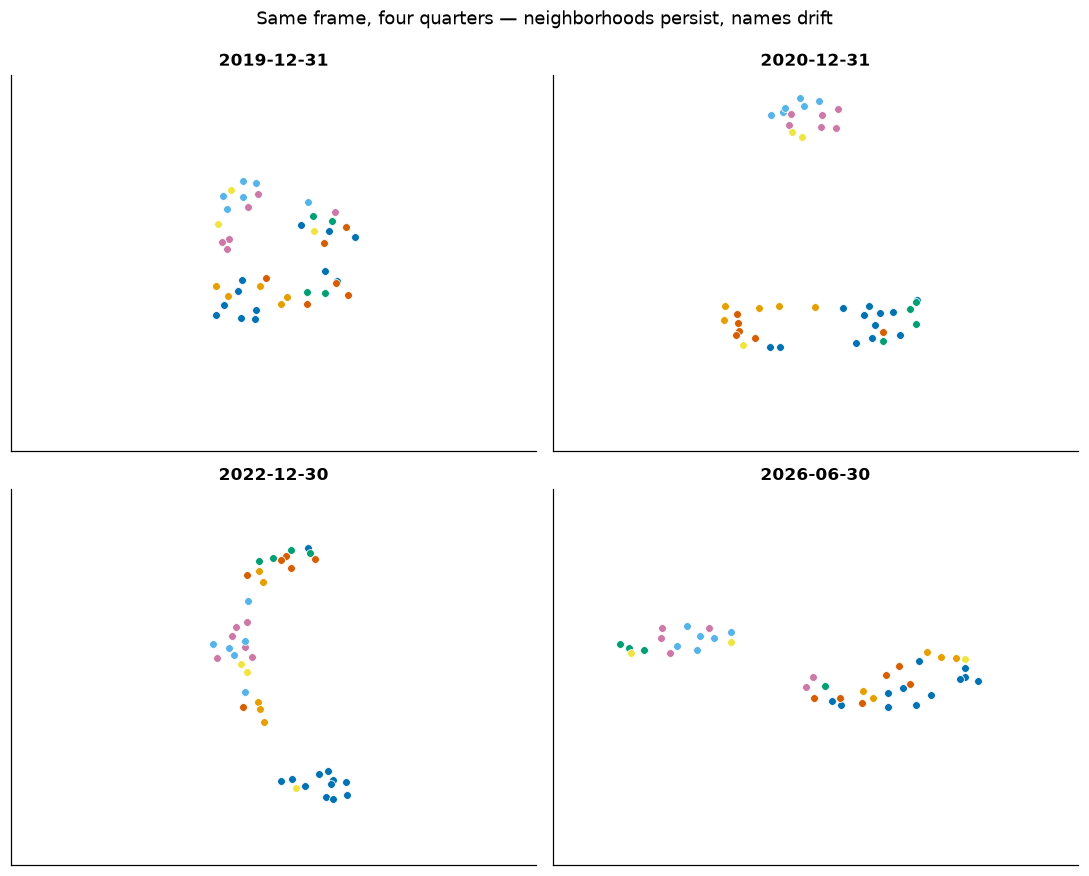

In [3]:
qs = [pd.Timestamp(t) for t in emb.times_]
picks = [qs.index(min(qs, key=lambda d, y=y: abs((d - pd.Timestamp(f"{y}-12-31")).days)))
         for y in (2019, 2020, 2022)] + [len(qs) - 1]
valid = ~np.isnan(E[..., 0])
xlim = (np.nanmin(E[..., 0]) - 1, np.nanmax(E[..., 0]) + 1)
ylim = (np.nanmin(E[..., 1]) - 1, np.nanmax(E[..., 1]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, t in zip(axes.ravel(), picks):
    draw_map(ax, t)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(str(pd.Timestamp(emb.times_[t]).date()))
plt.suptitle("Same frame, four quarters — neighborhoods persist, names drift", y=0.99)
plt.tight_layout()

### How to read this

All four panels share one coordinate frame — something that is only possible because alignment removed the arbitrary rotation and reflection between refits. The defensive island stays in its corner across the four panels; the growth continent stays in its region. What *does* change between panels is real: the growth cloud tightens and disperses as regimes change, and individual names wander between neighborhoods.

For contrast, imagine these four panels without stabilization: each would be arbitrarily rotated and mirrored relative to the others — four visually unrelated pictures, with no notion of a trajectory connecting a stock's positions across them.

## 3. Quantifying it: stabilized vs. naive re-embedding

Pictures can flatter, so we measure. For both workflows — naive independent re-embedding each quarter, and the stabilized chain — we compute how far the median stock moves on the map from one quarter to the next.

median quarterly movement per stock —
  naive independent UMAP : 7.07
  RollingEmbedding       : 1.76   (4.0x calmer)

largest structural reshuffles:
2023-06-30    4.93
2023-03-31    4.35
2023-09-29    3.90
2022-12-30    3.73


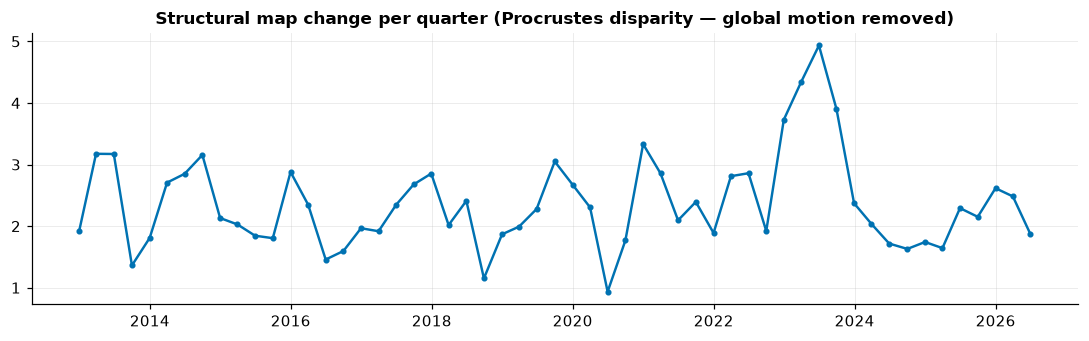

In [4]:
from quantroll.core.rolling_embedding import make_backend

run = make_backend("umap", 2, 0, dict(n_neighbors=10, min_dist=0.15, n_epochs=200))
prev, naive_moves = None, []
for d in emb.times_:
    X = panel.loc[d]
    s = pd.DataFrame(run(X.to_numpy(), None), index=X.index)
    if prev is not None:
        common = s.index.intersection(prev.index)
        naive_moves.append(np.median(np.sqrt(
            ((s.loc[common] - prev.loc[common]) ** 2).sum(axis=1))))
    prev = s

stab = np.nanmedian(emb.displacement_)
print(f"median quarterly movement per stock —")
print(f"  naive independent UMAP : {np.median(naive_moves):.2f}")
print(f"  RollingEmbedding       : {stab:.2f}   "
      f"({np.median(naive_moves)/stab:.1f}x calmer)")

dpar = pd.Series(emb.disparity_, index=pd.DatetimeIndex(emb.times_))
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(dpar.index, dpar, color=PAL[0], marker="o", ms=3)
ax.set_title("Structural map change per quarter (Procrustes disparity — global motion removed)")
plt.tight_layout()
print("\nlargest structural reshuffles:")
print(dpar.nlargest(4).round(2).to_string())

### How to read this

The naive workflow moves the median stock several map-units *every quarter* — and almost all of that motion is rotation/reflection noise, not behavior. The stabilized chain moves it a fraction of the distance, and what remains *is* behavior.

The second series, **disparity**, deserves its own definition: it is the residual difference between consecutive maps *after* the best global rotation/shift has been removed — that is, genuine reorganization of who-resembles-whom, with the layout's arbitrary motion subtracted out. Check the printed peak dates: the largest reshuffles land in **late 2020** (the vaccine-announcement value/growth rotation) and **2022–23** (the inflation shock, then the AI re-rating) — the two great regime rotations of the sample, discovered by geometry alone. This series is the map-space cousin of the PCA similarity trace from notebook 01: a structural-change signal that stabilization produces as a by-product.

## 4. Trajectories, and what the map is genuinely good at

With consecutive maps comparable, we can draw a stock's *trajectory* — its path across the map over the decade. Below, the final map in gray with two smoothed decade-long paths drawn on top: KO (Coca-Cola) and NVDA.

quarters when the whole map reorganized (average displacement, top 4):
  2023-06-30  avg 4.8   biggest movers: TSLA (8.0), BA (7.2), AMZN (6.7)
  2023-03-31  avg 4.2   biggest movers: NFLX (7.2), SLB (6.5), GE (6.4)
  2023-09-29  avg 3.4   biggest movers: CAT (7.7), CRM (7.5), SLB (6.8)
  2020-12-31  avg 3.1   biggest movers: MCD (6.5), UNH (6.3), KO (5.2)


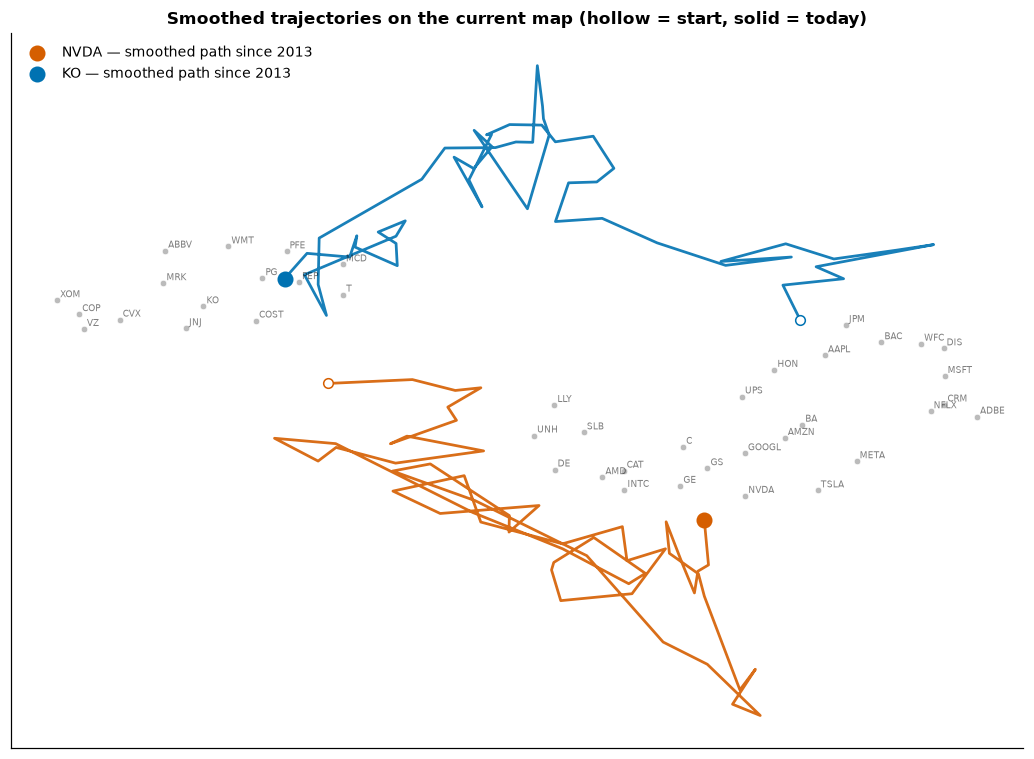

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 7))
coords = pd.DataFrame(E[-1], index=emb.entity_names_, columns=["x", "y"]).dropna()
ax.scatter(coords["x"], coords["y"], s=18, color="#bbbbbb",
           edgecolor="white", linewidth=0.4)
for t_, (x, y) in coords.iterrows():
    ax.annotate(t_, (x, y), fontsize=6, alpha=0.5, xytext=(2, 2),
                textcoords="offset points")
for tkr, colr in [("NVDA", PAL[5]), ("KO", PAL[0])]:
    tr = emb.trajectory(tkr).dropna().rolling(4).mean().dropna()
    ax.plot(tr["e1"], tr["e2"], color=colr, lw=1.8, alpha=0.9)
    ax.scatter(tr["e1"].iloc[-1], tr["e2"].iloc[-1], s=90, color=colr,
               zorder=5, label=f"{tkr} — smoothed path since 2013")
    ax.scatter(tr["e1"].iloc[0], tr["e2"].iloc[0], s=40, color=colr,
               facecolor="white", zorder=5)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.legend(loc="upper left")
ax.set_title("Smoothed trajectories on the current map (hollow = start, solid = today)")
plt.tight_layout()

disp = pd.DataFrame(emb.displacement_, index=pd.DatetimeIndex(emb.times_),
                    columns=emb.entity_names_)
sync = disp.mean(axis=1)
print("quarters when the whole map reorganized (average displacement, top 4):")
for d, v in sync.nlargest(4).items():
    movers = disp.loc[d].nlargest(3)
    print(f"  {d.date()}  avg {v:.1f}   biggest movers: "
          + ", ".join(f"{t} ({m:.1f})" for t, m in movers.items()))

### How to read this — and an honest division of labor

The smoothed paths give a correct *qualitative* picture: KO spends its entire decade inside the defensive lowland, while NVDA's path ends at the momentum frontier. But resist making *quantitative per-name* claims from raw trajectories. At quarterly frequency, an individual dot's movement is dominated by the layout *breathing* — small global expansions and contractions that no rigid rotation can remove, so alignment cannot subtract them. Compute raw path lengths and calm, stationary KO travels nearly as far as NVDA, because every dot inherits the map's ambient jitter.

What map displacement measures *well* is shown in the printed table: displacement is **synchronized**. The quarters in which stocks move most are shared across the whole universe, and they land exactly on the disparity peaks from section 3 — late 2020 and 2022–23. The map, in other words, is an instrument for **collective reorganization events** — regime rotations you can watch happen. For *per-name* style drift, the sharper instrument is the cluster-switch count from notebook 03. Knowing which instrument answers which question is half the craft.

## 5. Production shape

Quarterly `update()` continues the same alignment chain and is bit-identical to a full refit (verified below). A stock that IPOs mid-history is placed on arrival next to its nearest behavioral neighbors in *feature* space, then tracked like any other — the unbalanced-panel handling is automatic.

In [6]:
times = list(emb.times_)
head = panel[panel.index.get_level_values(0) < times[-4]]
tail = panel[panel.index.get_level_values(0) >= times[-4]]
emb2 = RollingEmbedding(backend="umap", seed=0,
                        backend_kwargs=dict(n_neighbors=10, min_dist=0.15,
                                            n_epochs=200)).fit(head)
emb2.update(tail)
print("fit(head) + 4 quarterly updates == fit(everything):",
      np.allclose(emb2.embeddings_, emb.embeddings_, equal_nan=True))

fit(head) + 4 quarterly updates == fit(everything): True


## What you now have, and what it's worth

| Output | Use it for |
|---|---|
| A stable quarterly universe map | committee-ready structure at a glance; onboarding a new analyst with one picture |
| Sector-free neighborhoods | find true behavioral peers, and the names whose sector label lies |
| Disparity series | a geometric regime-rotation flag (vaccine rotation, 2022–23 reshuffle) |
| Trajectories & path lengths | style-drift evidence you can *show*, corroborating notebook 03's counts |
| 3–4× churn reduction vs naive UMAP | movement on the map means movement in behavior |

**Next:** notebook `05` closes the series with explainable multi-measure asset selection.